In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:

########################################
# 1. PARAMETERS
########################################

alpha = 0.191      # infection rate
beta = 0.05    # recovery rate
mu = 0.0294     # mortality rate

N = 59e6
S_0 = N - 1
I_0 = 1
R_0 = 0
D_0 = 0
S0 = S_0 / N
I0 = I_0 / N
R0 = R_0 / N
D0 = D_0 / N

In [3]:

########################################
# 2. ODE SOLUTION
########################################

def deriv(y, t, alpha, beta, mu):
    S, I, R, D = y
    dSdt = -alpha * S * I
    dIdt = alpha * S * I - beta * I - mu * I
    dRdt = beta * I
    dDdt = mu * I
    return [dSdt, dIdt, dRdt, dDdt]

# time space for ODE solution
t = np.linspace(0, 500, 1000)

y0 = [S0, I0, R0, D0]

ret = odeint(deriv, y0, t, args=(alpha, beta, mu))
S_ode, I_ode, R_ode, D_ode = ret.T


In [4]:
########################################
# 3. TRAINING POINTS & DATA
########################################

t_start = 0
t_end = 500
n_points = 1000


t_train = torch.linspace(t_start, t_end, n_points).view(-1, 1).to(device)
t_train.requires_grad = True

S_train = torch.tensor(S_ode).view(-1, 1).to(device)
I_train = torch.tensor(I_ode).view(-1, 1).to(device)
R_train = torch.tensor(R_ode).view(-1, 1).to(device)
D_train = torch.tensor(D_ode).view(-1, 1).to(device)

In [5]:
########################################
# 4. PINN MODEL
########################################

class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),
            
            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),
            
            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),
            
            nn.Linear(64, 4)
        )

    def forward(self, t):
        # Softplus ensures outputs are positive
        return torch.nn.functional.softplus(self.net(t))

model = PINN().to(device)


In [6]:
########################################
# 5. PHYSICS LOSS
########################################

def physics_loss():

    pred = model(t_train)

    S = pred[:, 0:1]
    I = pred[:, 1:2]
    R = pred[:, 2:3]
    D = pred[:, 3:4]

    dS_dt = torch.autograd.grad(S, t_train, torch.ones_like(S), create_graph=True)[0]
    dI_dt = torch.autograd.grad(I, t_train, torch.ones_like(I), create_graph=True)[0]
    dR_dt = torch.autograd.grad(R, t_train, torch.ones_like(R), create_graph=True)[0]
    dD_dt = torch.autograd.grad(D, t_train, torch.ones_like(D), create_graph=True)[0]

    eq1 = dS_dt + alpha * S * I
    eq2 = dI_dt - alpha * S * I + (beta + mu) * I
    eq3 = dR_dt - beta * I
    eq4 = dD_dt - mu * I

    return (
        torch.mean(torch.square(eq1)) 
        + torch.mean(torch.square(eq2))
        + torch.mean(torch.square(eq3))
        + torch.mean(torch.square(eq4))
    )

In [7]:
########################################
# 6. INITIAL CONDITION LOSS
########################################

def initial_condition_loss():

    t0 = torch.tensor([[0.0]], device=device)
    pred0 = model(t0)

    S_pred = pred0[:, 0]
    I_pred = pred0[:, 1]
    R_pred = pred0[:, 2]
    D_pred = pred0[:, 3]

    return (
        (torch.square(S_pred - S0)) +
        (torch.square(I_pred - I0)) +
        (torch.square(R_pred - R0)) +
        (torch.square(D_pred - D0))
    ).mean()
    

In [8]:
########################################
# Data Loss
########################################

def data_loss():
    
    pred = model(t_train)

    S = pred[:, 0:1]
    I = pred[:, 1:2]
    R = pred[:, 2:3]
    D = pred[:, 3:4]

    loss_S = torch.mean(torch.square(S - S_train))
    loss_I = torch.mean(torch.square(I - I_train))
    loss_R = torch.mean(torch.square(R - R_train))
    loss_D = torch.mean(torch.square(D - D_train))

    return loss_S + loss_I + loss_R + loss_D

In [9]:
########################################
# 8. OPTIMIZER
########################################

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.CyclicLR(
    optimizer,
    mode="exp_range",
    base_lr=1e-5,
    max_lr=1e-3,
    step_size_up=100,
    gamma=0.85
)

In [10]:
########################################
# 9. TRAINING LOOP
########################################

epochs = 50000
loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    loss_pde = physics_loss()
    loss_ic = initial_condition_loss()
    # loss_pop = population_loss()
    loss_data = data_loss()

    loss = ( loss_pde + loss_ic  + loss_data )

    loss.backward()
    optimizer.step()
    scheduler.step()

    loss_history.append(loss.item())

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 2.723769
Epoch 1000, Loss: 1.661453
Epoch 2000, Loss: 0.395291
Epoch 3000, Loss: 0.031758
Epoch 4000, Loss: 0.014391
Epoch 5000, Loss: 0.009082
Epoch 6000, Loss: 0.006588
Epoch 7000, Loss: 0.005580
Epoch 8000, Loss: 0.004889
Epoch 9000, Loss: 0.004096
Epoch 10000, Loss: 0.003527
Epoch 11000, Loss: 0.003311
Epoch 12000, Loss: 0.003257
Epoch 13000, Loss: 0.003239
Epoch 14000, Loss: 0.003211
Epoch 15000, Loss: 0.002256
Epoch 16000, Loss: 0.000992
Epoch 17000, Loss: 0.000453
Epoch 18000, Loss: 0.000182
Epoch 19000, Loss: 0.000081
Epoch 20000, Loss: 0.000042
Epoch 21000, Loss: 0.000024
Epoch 22000, Loss: 0.000015
Epoch 23000, Loss: 0.000010
Epoch 24000, Loss: 0.000007
Epoch 25000, Loss: 0.000006
Epoch 26000, Loss: 0.000005
Epoch 27000, Loss: 0.000004
Epoch 28000, Loss: 0.000003
Epoch 29000, Loss: 0.000003
Epoch 30000, Loss: 0.000003
Epoch 31000, Loss: 0.000002
Epoch 32000, Loss: 0.000002
Epoch 33000, Loss: 0.000002
Epoch 34000, Loss: 0.000002
Epoch 35000, Loss: 0.000002
Epoch

In [11]:
########################################
# 10. PREDICTION
########################################

n_testpoints = 1000
t_test = torch.linspace(0, 500, n_testpoints).view(-1, 1).to(device)

with torch.no_grad():
    pred = model(t_test)

S = pred[:, 0].cpu().numpy()
I = pred[:, 1].cpu().numpy()
R = pred[:, 2].cpu().numpy()
D = pred[:, 3].cpu().numpy()

t_np = t_test.cpu().numpy()

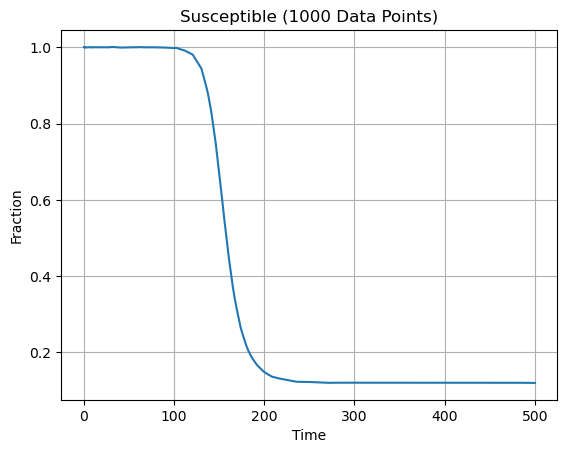

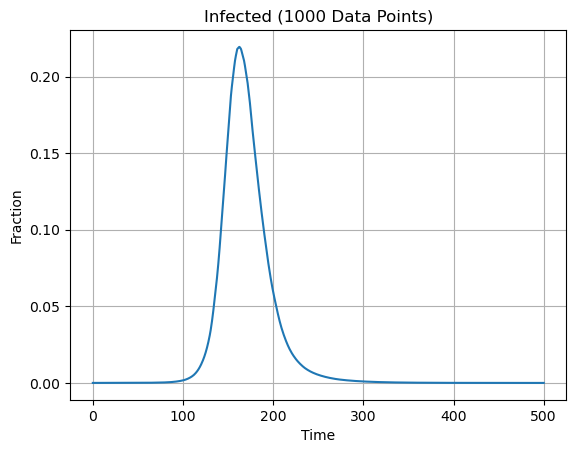

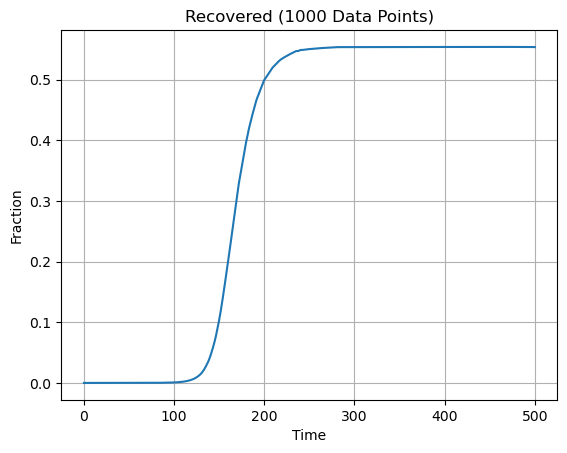

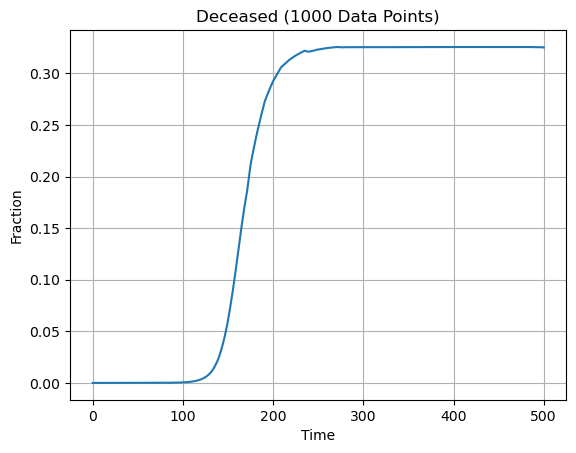

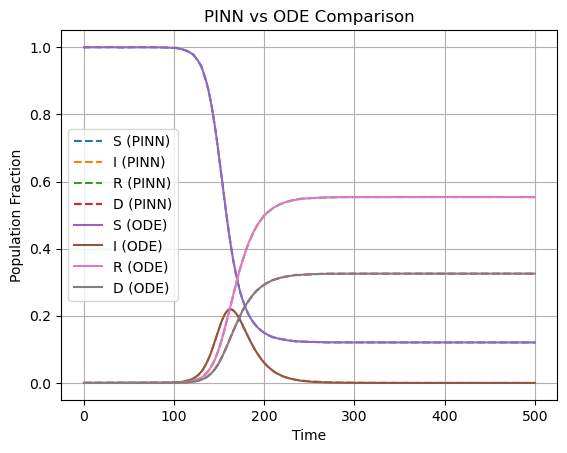

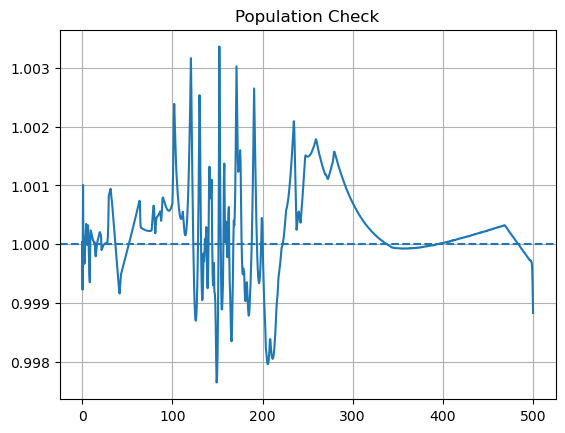

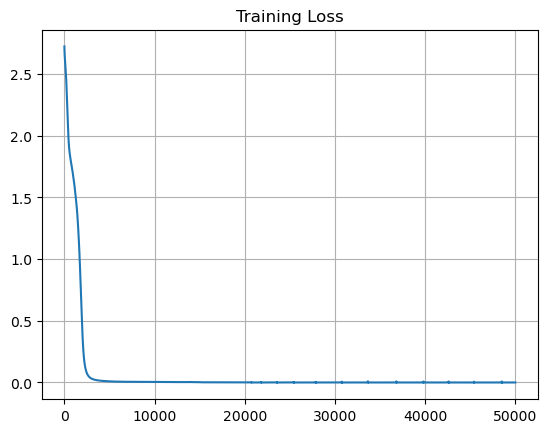

In [12]:
########################################
# 11. INDIVIDUAL PLOTS
########################################

plt.figure()
plt.plot(t_np, S)
plt.title("Susceptible (1000 Data Points)")
plt.xlabel("Time")
plt.ylabel("Fraction")
plt.grid()
plt.show()

plt.figure()
plt.plot(t_np, I)
plt.title("Infected (1000 Data Points)")
plt.xlabel("Time")
plt.ylabel("Fraction")
plt.grid()
plt.show()

plt.figure()
plt.plot(t_np, R)
plt.title("Recovered (1000 Data Points)")
plt.xlabel("Time")
plt.ylabel("Fraction")
plt.grid()
plt.show()

plt.figure()
plt.plot(t_np, D)
plt.title("Deceased (1000 Data Points)")
plt.xlabel("Time")
plt.ylabel("Fraction")
plt.grid()
plt.show()

########################################
# 12. COMBINED PLOT
########################################

plt.figure()

# PINN
plt.plot(t_np, S, '--', label="S (PINN)")
plt.plot(t_np, I, '--', label="I (PINN)")
plt.plot(t_np, R, '--', label="R (PINN)")
plt.plot(t_np, D, '--', label="D (PINN)")

# ODE (ground truth)
plt.plot(t_np, S_ode, label="S (ODE)")
plt.plot(t_np, I_ode, label="I (ODE)")
plt.plot(t_np, R_ode, label="R (ODE)")
plt.plot(t_np, D_ode, label="D (ODE)")

plt.legend()
plt.title("PINN vs ODE Comparison")
plt.xlabel("Time")
plt.ylabel("Population Fraction")
plt.grid()
plt.show()

########################################
# 12. CONSERVATION CHECK
########################################

total = S + I + R + D

plt.figure()
plt.plot(t_np, total)
plt.axhline(1.0, linestyle='--')
plt.title("Population Check")
plt.grid()
plt.show()

########################################
# 13. LOSS PLOT
########################################

plt.figure()
plt.plot(loss_history)
plt.title("Training Loss")
plt.grid()
plt.show()